In [427]:
# Necessary libraries and useful parameters
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
newparams = {'font.family': 'cmr10', 'mathtext.fontset': 'cm',
             'axes.grid': False, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20,
             'axes.formatter.use_mathtext': True}
plt.rcParams.update(newparams)
%matplotlib inline

In [463]:
# A 2D plot-maker of C
def contour_plot(Z, R, C, cmap='viridis', cbar_label=r'$c$ [mol/L]'):
    contour = plt.contourf(Z, R, C, levels=200, cmap=cmap, vmin=0, vmax=1500)
    cbar = plt.colorbar(contour, label=cbar_label)
    
    plt.xlabel('$z/L$')
    plt.ylabel('$r/R$')
    plt.gca().set_aspect(aspect=0.6, adjustable='box')
    

In [474]:
# Global model parameters
R, L, tf = 1, 1, 3000
domain = [[0, R], [0, L], [0, tf]]

D, A, B = 1.5, 5.5, 1

M, K = 100, 1
h, ht = 1/M, 1/K

z = np.linspace(domain[1][0], domain[1][1], M+1)
r = np.linspace(domain[0][0], domain[0][1], M+1)
t = np.arange(domain[2][0], domain[2][1], ht)

grid = [z, r]
ZZ, RR = np.meshgrid(z, r) 

In [475]:
# Block matrix coefficients
delta = ht/h**2 * D
gamma = delta * (R/L)**2
alpha = ht/h * A/r
beta = ht/h * B*(1-r**2)
omega = beta - alpha - 2*(gamma + delta) - 1

/var/folders/h0/88jjy3r533d1nj8s86kss9b80000gn/T/ipykernel_41390/947139071.py:4: RuntimeWarning: divide by zero encountered in divide
  alpha = ht/h * A/r


In [476]:
def coeff_matrix(M):
    Z = (M-1)**2

    ll = np.full(Z, delta)                          # Lowest diag
    l = np.repeat(gamma - beta[1:-1], M-1)          # Next lowest diag
    d = np.repeat(omega[1:-1], M-1)                 # Main diag
    u = np.full(Z, gamma)                           # Next highest diag
    uu = np.repeat(delta + alpha[1:-1], M-1)[M-1:]  # Highest diag
    
    l[M-2::M-1], u[M-2::M-1] = 0, 0    # Every M-1'th element is zero in l and d
    
    A = sp.diags([ll, l, d, u, uu], [-(M-1), -1, 0, 1, M-1], (Z, Z), format='csr')

    return A

In [477]:
def boundary_vector(grid, k, BC, M):
  z, r = grid
  g1, g2, g3, g4 = BC
  
  # Construct a matrix containing boundary contributions.
  G = np.zeros((M-1, M-1))
  G[:, 0][::-1] += (gamma-beta[1:-1]) * g1(r[1:-1], t[k+1])
  G[-1, :] += delta * g2(z[1:-1], t[k+1])
  G[:, -1][::-1] += gamma * g3(r[1:-1], t[k+1])
  G[0, :] += (delta+alpha[1:-1]) * g4(z[1:-1], t[k+1])

  return G[::-1].ravel()

In [478]:
def boundary_vector2(grid, k, BC, M):
    r, z = grid
    g1, g2, g3, g4 = BC

    # Create the first part of the vector
    first_part = [delta * g2(r[i], t[k+1]) for i in range(1, M)]
    
    # Create the middle part with zeros
    middle_part = [0 for _ in range(M, (M - 1)**2 - (M - 2))]
    
    # Create the end part of the vector
    end_part = [(delta + alpha[M-1]) * g4(r[i - ((M-1)**2 - (M-1))], t[k+1])
                for i in range((M-1)**2 - (M-2), (M-1)**2 + 1)]
    
    # Combine all parts into the boundary vector
    vector = first_part + middle_part + end_part
    g1_count = 1
    g3_count = 1
    
    # Update the boundary_vector according to the given conditions
    for i in range(0, (M-1)**2):
        if i % (M-1) == 0:  # For the g term
            vector[i] += (gamma-beta[g1_count]) * g1(r[g1_count], t[k+1]) 
            g1_count += 1
            
        if (i % (M-1)) == M-2:  # For the p term
            vector[i] += gamma * g3([g3_count], t[k+1]) 
            g3_count += 1

    return vector

In [479]:
def concentration_scheme(grid, k, A, Ck, g, BC, M):
    '''Calculates Ck+1 given time step k and previus soln Ck'''
    z, r = grid
    g1, g2, g3, g4 = BC
   
    C = np.zeros((M+1, M+1))
    C[:, 0][::-1] = g1(r, t[k+1])   # Left bnd
    C[-1, :] = g2(z, t[k+1])        # Bottom bnd
    C[:, -1][::-1] = g3(r, t[k+1])  # Right bnd
    C[0, :] = g4(z, t[k+1])         # Top bnd
   
    C_interior = sp.linalg.spsolve(A, -(g + Ck[1:-1, 1:-1][::-1].ravel()))
    C[1:-1, 1:-1] = np.reshape(C_interior, (M-1, M-1))
   
    return C

In [487]:
# Initial condition
def f(z, r):
    return np.zeros_like(ZZ)

# Boundary conditions
def i(r, t): # Concentration in
    return 1000
def e(z, t): # Electric
    return np.zeros_like(z)
# def o(r, t): # Concentration out 
#     # return np.zeros_like(r)
#     time_step_wait = 700
#     # return i(r,t)- np.log((np.exp(t) + 1)/ (np.exp(t-time_step_wait*ht) + 1)) if t > time_step_wait*ht else 0
#     # return i(r, t) - (np.logaddexp(t, 0) - np.logaddexp(t - time_step_wait * ht, 0)) if t > time_step_wait * ht else 0
#     # return i(r, t) - (np.logaddexp(t, 0) - np.logaddexp(t - time_step_wait * ht, 0))
#     delay = 700 * ht
#     if t < delay:
#         return 0
#     return i(r, t - delay) - d(r, t - delay)
#     # return 0
#     # return np.zeros_like(r)
def o(c):
    """
        Here, a Neumann condition where the concentration at the outlet is equal to the concentration right before the outlet.
    """
    return c[-2] 
def d(z, t): # Deposition Function
    # return np.log((np.exp(t) + 1)/2)
    return np.logaddexp(t, 0) - np.log(2) # Numerically stable
    # return t

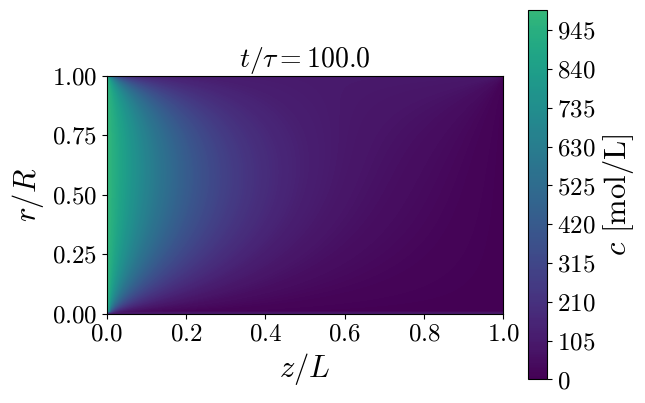

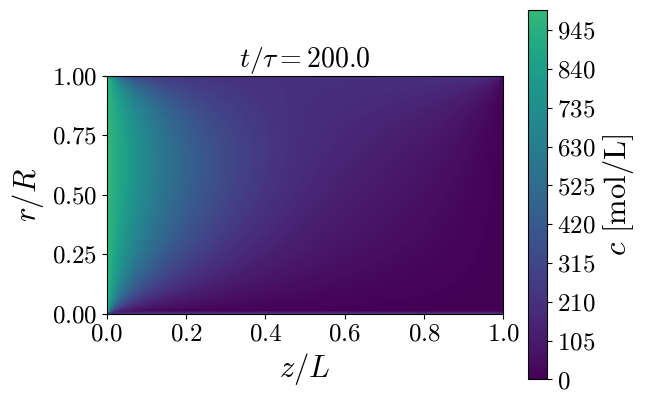

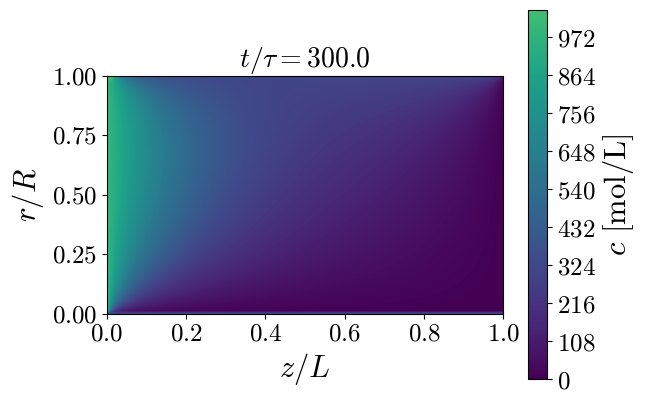

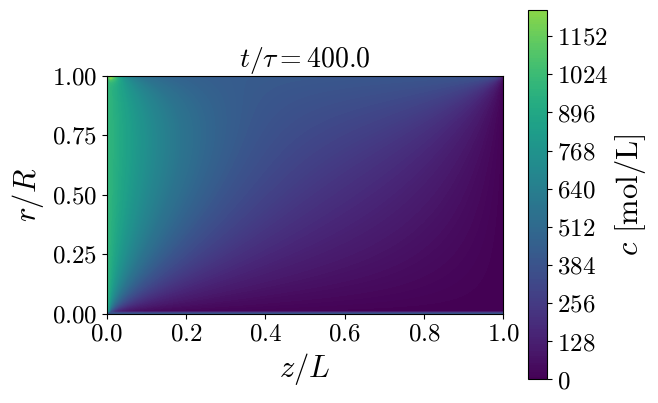

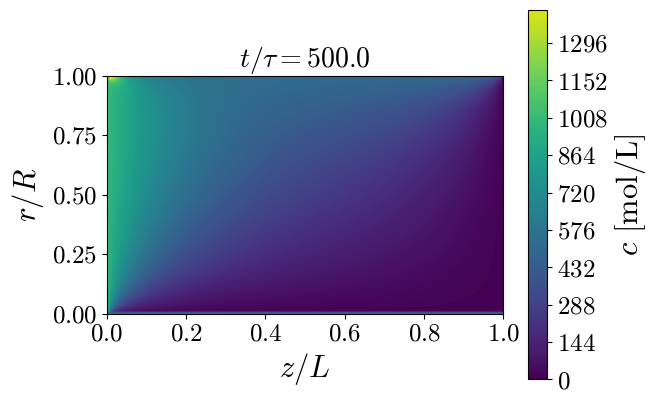

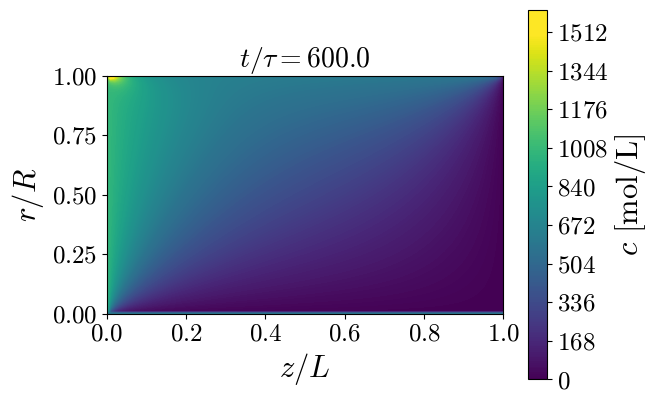

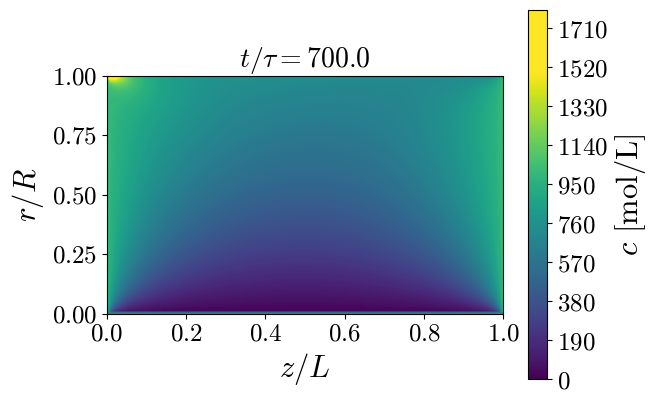

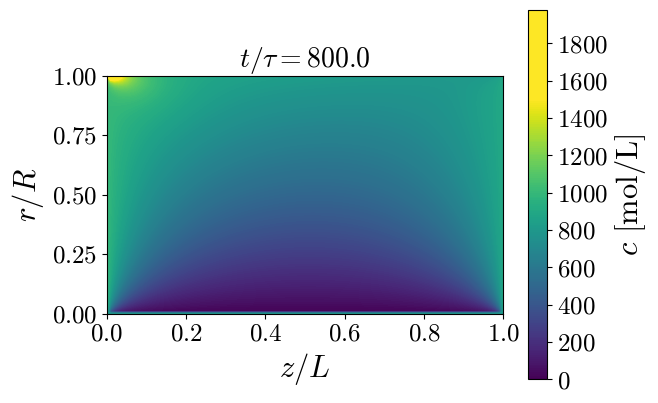

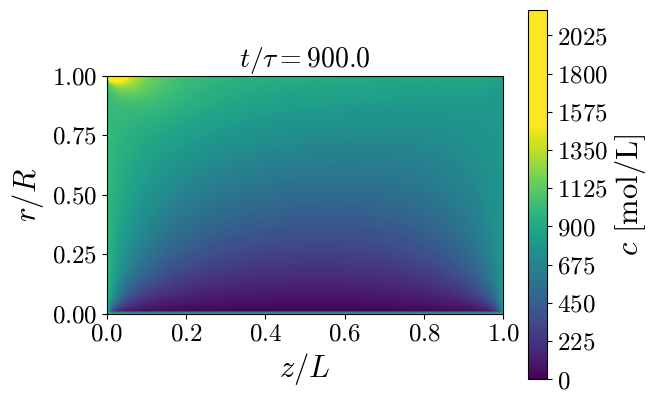

KeyboardInterrupt: 

In [488]:
# Example
BC = [i, e, o, d]
A_matr = coeff_matrix(M)
C0 = f(z, r) # Initial concentration matrix

Ck = C0
alphanumeric = 65
for k in range(len(t)-1):
    g = boundary_vector(grid, k, BC, M)
    C = concentration_scheme(grid, k, A_matr, Ck, g, BC, M)
    
    if (k+1) % 100 == 0:  # Plot every 10th iteration
        plt.figure()
        plt.title(f'$t/\\tau= {(k+1)/K}$')
        contour_plot(ZZ, RR, C)
        plt.savefig(f"output/{chr(alphanumeric)}.png", bbox_inches='tight')
        plt.show()
        alphanumeric += 1
    
    Ck = C

In [444]:
from PIL import Image
import os
import glob

img = [] # some array of images
frames = [] # for storing the generated images
fig = plt.figure()
files = glob.glob("./output/*.png")
files = sorted(files)

images = [Image.open(img).convert('RGB') for img in files]

images[0].save(
    'fds.gif',
    save_all=True,
    append_images=images[1:],  # remaining frames
    duration=300,              # duration per frame in milliseconds
    loop=0                     # loop forever
)

<Figure size 640x480 with 0 Axes>